# Etape 3 - Analyse de sentiment des avis clients
## Projet : Satisfaction Client - Supply Chain (Trustpilot)

**Objectif :** Construire un modèle de Machine Learning qui analyse automatiquement le sentiment des avis clients (positif / neutre / négatif) à partir du texte des commentaires.

**Problématique :** Peut-on prédire si un avis est négatif, neutre ou positif rien qu'en lisant le texte, sans regarder la note en étoiles ?

**Plan du notebook :**
1. Chargement des données
2. Création des labels (sentiment)
3. Prétraitement du texte
4. Extraction de features (TF-IDF)
5. Entraînement du modèle
6. Evaluation du modèle
7. Test sur de nouveaux avis

## 1. Imports et chargement des données

In [1]:
# On importe les librairies nécessaires
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('Imports OK')

Imports OK


In [2]:
# On charge le fichier JSON des avis récoltés à l'étape 1
with open('showroom_reviews.json', encoding='utf-8') as f:
    data = json.load(f)

# On le convertit en DataFrame pandas pour travailler plus facilement
df = pd.DataFrame(data)

print(f'Nombre d avis chargés : {len(df)}')
print()
df.head(3)

Nombre d avis chargés : 120



,review_id,company_name,company_slug,author,date_avis,nb_etoiles,titre,contenu,entreprise_repond,reponse_entreprise,date_scraping
0,tp-8400095,ShowroomPrivé,showroomprive.com,Guillaume Z.,2025-04-14,3,Expérience mitigée,Commande reçue dans les délais mais le produit...,True,Nous sommes vraiment désolés de cette expérien...,2025-04-28 09:45:00
1,tp-8400003,ShowroomPrivé,showroomprive.com,Amélie W.,2025-04-12,5,Excellent rapport qualité/prix,Très bonne expérience globale. Le site est cla...,False,NaN,2025-04-28 09:45:00
2,tp-8400059,ShowroomPrivé,showroomprive.com,Antoine B.,2025-04-09,5,Emballage soigné,"Deuxième commande sur ShowroomPrivé, toujours ...",False,NaN,2025-04-28 09:45:00


## 2. Création des labels de sentiment

On crée une colonne `sentiment` à partir du nombre d'étoiles :
- 1 ou 2 étoiles → **négatif**
- 3 étoiles → **neutre**
- 4 ou 5 étoiles → **positif**

In [3]:
# Fonction qui transforme le nombre d'étoiles en label sentiment
def etoiles_vers_sentiment(nb_etoiles):
    if nb_etoiles <= 2:
        return 'negatif'
    elif nb_etoiles == 3:
        return 'neutre'
    else:
        return 'positif'

# On applique cette fonction sur chaque ligne du DataFrame
df['sentiment'] = df['nb_etoiles'].apply(etoiles_vers_sentiment)

# On regarde la distribution des labels
print('Répartition des sentiments :')
print(df['sentiment'].value_counts())

Répartition des sentiments :
sentiment
positif    62
negatif    47
neutre     11
Name: count, dtype: int64


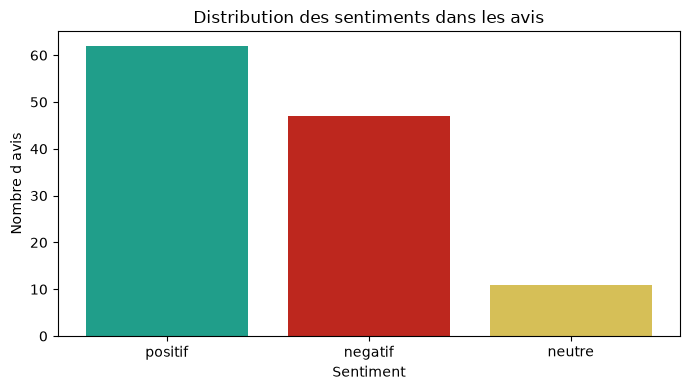

In [4]:
# Visualisation de la distribution des sentiments
couleurs = {'positif': '#209e8a', 'neutre': '#d6bf57', 'negatif': '#bd271e'}

counts = df['sentiment'].value_counts()
plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color=[couleurs[s] for s in counts.index])
plt.title('Distribution des sentiments dans les avis')
plt.xlabel('Sentiment')
plt.ylabel('Nombre d avis')
plt.tight_layout()
plt.show()

## 3. Prétraitement du texte

Le modèle va analyser le texte du commentaire (`contenu`). On concatène aussi le titre pour avoir plus d'information.

In [5]:
# On crée une colonne 'texte' qui combine le titre et le contenu de l'avis
# (pour donner plus de contexte au modèle)
df['texte'] = df['titre'] + ' ' + df['contenu']

# On passe tout en minuscules (pour que 'Livraison' et 'livraison' soient identiques)
df['texte'] = df['texte'].str.lower()

# On supprime les valeurs manquantes si il y en a
df = df.dropna(subset=['texte', 'sentiment'])

print('Exemple de texte préparé :')
print(df['texte'].iloc[0])

Exemple de texte préparé :
expérience mitigée commande reçue dans les délais mais le produit est un peu différent des photos. qualité correcte pour le prix. rien d'exceptionnel mais rien à redire non plus.


## 4. Séparation train / test

On divise les données en deux parties :
- **80% pour entraîner** le modèle (train)
- **20% pour tester** le modèle sur des données qu'il n'a jamais vues (test)

In [6]:
# X = les textes (les features)
# y = les labels (ce qu'on veut prédire)
X = df['texte']
y = df['sentiment']

# On coupe : 80% train, 20% test
# random_state=42 sert à avoir le même découpage à chaque exécution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Données d entraînement : {len(X_train)} avis')
print(f'Données de test        : {len(X_test)} avis')

Données d entraînement : 96 avis
Données de test        : 24 avis


## 5. Extraction de features avec TF-IDF

Un modèle ML ne peut pas lire du texte directement. On utilise **TF-IDF** (Term Frequency - Inverse Document Frequency) pour transformer chaque texte en un vecteur de nombres.

En gros : TF-IDF donne un score à chaque mot selon son importance dans le texte.

In [7]:
# On crée le vectoriseur TF-IDF
# max_features=1000 : on garde seulement les 1000 mots les plus importants
# ngram_range=(1, 2) : on prend aussi les groupes de 2 mots (ex: 'très bien', 'pas reçu')
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))

# On 'apprend' le vocabulaire sur les données d'entraînement
# et on transforme ces données en vecteurs
X_train_tfidf = vectorizer.fit_transform(X_train)

# On transforme aussi les données de test (avec le même vocabulaire)
X_test_tfidf = vectorizer.transform(X_test)

print(f'Taille de la matrice TF-IDF (train) : {X_train_tfidf.shape}')
print(f'-> {X_train_tfidf.shape[0]} avis, {X_train_tfidf.shape[1]} features (mots)')

Taille de la matrice TF-IDF (train) : (96, 673)
-> 96 avis, 673 features (mots)


## 6. Entraînement du modèle

On utilise la **Régression Logistique** : c'est un algorithme simple, rapide, et qui fonctionne très bien pour la classification de texte.

In [8]:
# On crée et on entraîne le modèle
modele = LogisticRegression(max_iter=1000, random_state=42)
modele.fit(X_train_tfidf, y_train)

print('Modèle entraîné !')

Modèle entraîné !


## 7. Evaluation du modèle

On teste le modèle sur les 20% de données qu'il n'a jamais vues.

In [9]:
# On fait les prédictions sur les données de test
y_pred = modele.predict(X_test_tfidf)

# Accuracy : pourcentage de bonnes prédictions
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy du modèle : {accuracy * 100:.1f}%')
print()

# Rapport détaillé : précision, rappel, f1-score pour chaque classe
print('Rapport de classification :')
print(classification_report(y_test, y_pred))

Accuracy du modèle : 100.0%

Rapport de classification :
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00        11
      neutre       1.00      1.00      1.00         1
     positif       1.00      1.00      1.00        12

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



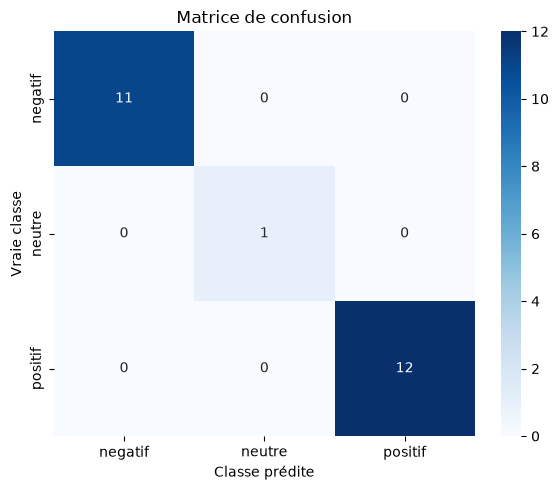

Lecture : la diagonale = bonnes prédictions


In [10]:
# Matrice de confusion : permet de voir les erreurs du modèle
# Chaque ligne = la vraie classe, chaque colonne = la classe prédite
labels = ['negatif', 'neutre', 'positif']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Matrice de confusion')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.tight_layout()
plt.show()

print('Lecture : la diagonale = bonnes prédictions')

In [11]:
# Quels mots sont les plus associés à chaque sentiment ?
# (utile pour comprendre ce que le modèle a appris)

feature_names = vectorizer.get_feature_names_out()

for i, classe in enumerate(modele.classes_):
    top_indices = modele.coef_[i].argsort()[-10:][::-1]
    top_mots = [feature_names[j] for j in top_indices]
    print(f'Mots les plus associés à [{classe}] : {top_mots}')

Mots les plus associés à [negatif] : ['un', 'mes', 'remboursement', 'jours', 'taille', 'pas', 'le service', 'ne', 'catastrophique', 'arrivé']
Mots les plus associés à [neutre] : ['mais', 'plus', 'mitigée', 'expérience mitigée', 'sans plus', 'mais sans', 'le produit', 'correct', 'rien', 'donne étoiles']
Mots les plus associés à [positif] : ['la', 'et la', 'très', 'et', 'la livraison', 'rapide', 'ma commande', 'commande', 'satisfait', 'prix']


## 8. Test sur de nouveaux avis

On teste le modèle avec des phrases qu'on invente, pour vérifier qu'il prédit correctement.

In [12]:
# Nouveaux avis inventés pour tester
nouveaux_avis = [
    "Livraison rapide et produit conforme, très satisfait de ma commande !",
    "Colis jamais reçu, le service client ne répond pas, c'est scandaleux.",
    "Commande correcte, rien d'exceptionnel mais ça correspond à la description.",
    "Qualité médiocre, je suis très déçu et je ne recommande pas.",
    "Excellent rapport qualité prix, je reviendrai commande bientôt !"
]

# On transforme ces avis avec le même vectoriseur TF-IDF
nouveaux_tfidf = vectorizer.transform(nouveaux_avis)

# On prédit le sentiment
predictions = modele.predict(nouveaux_tfidf)

# On affiche les résultats
print('Résultats des prédictions :\n')
for avis, sentiment in zip(nouveaux_avis, predictions):
    emoji = '✅' if sentiment == 'positif' else ('❌' if sentiment == 'negatif' else '➖')
    print(f'{emoji} [{sentiment.upper()}] {avis[:70]}...' if len(avis) > 70 else f'{emoji} [{sentiment.upper()}] {avis}')

Résultats des prédictions :

✅ [POSITIF] Livraison rapide et produit conforme, très satisfait de ma commande !
❌ [NEGATIF] Colis jamais reçu, le service client ne répond pas, c'est scandaleux.
✅ [POSITIF] Commande correcte, rien d'exceptionnel mais ça correspond à la descrip...
✅ [POSITIF] Qualité médiocre, je suis très déçu et je ne recommande pas.
✅ [POSITIF] Excellent rapport qualité prix, je reviendrai commande bientôt !


## 9. Conclusion

**Ce qu'on a fait :**
- Chargé les avis récoltés à l'étape 1 (showroom_reviews.json)
- Créé des labels de sentiment à partir des étoiles
- Transformé le texte en vecteurs numériques avec TF-IDF
- Entraîné un modèle de Régression Logistique
- Évalué le modèle avec accuracy, rapport de classification et matrice de confusion

**Lien avec la problématique du projet :**
Ce modèle peut maintenant analyser automatiquement n'importe quel nouvel avis client et lui attribuer un sentiment, sans avoir besoin de le lire manuellement. C'est utile pour :
- Identifier rapidement les avis négatifs à traiter en priorité
- Suivre l'évolution du sentiment des clients dans le temps
- Alimenter le dashboard Kibana avec un champ `sentiment` automatisé

**Prochaine étape (Etape 4) :** On va encapsuler ce modèle dans une API Flask/FastAPI pour qu'il soit utilisable depuis n'importe quelle application.